# 04 Provisional opportunity analysis

This notebook creates a transparent no-rent screening score
from demand, accessibility and competition opportunity. The
result is provisional and must be recalculated after commercial
asking-rent data is added.

## 1. Imports, constants and data loading

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FINAL_WEIGHTS,
    FIGURES_DIR,
    PARISH_ANALYSIS_BASE_FILE,
    PROVISIONAL_WEIGHTS,
    RANDOM_STATE,
    SENSITIVITY_ITERATIONS,
    TABLES_DIR,
)
from src.utils import inverse_percentile_score, save_figure

sns.set_theme(style="whitegrid", context="notebook")
df = pd.read_csv(PARISH_ANALYSIS_BASE_FILE)

component_columns = list(PROVISIONAL_WEIGHTS)
assert np.isclose(sum(PROVISIONAL_WEIGHTS.values()), 1.0)
assert not df[component_columns].isna().any().any()
PROVISIONAL_WEIGHTS

{'demand_proxy_score': 0.4117647058823529,
 'transit_access_score': 0.29411764705882354,
 'competition_opportunity_score': 0.29411764705882354}

## 2. Base provisional score

The planned demand, accessibility and competition weights are
renormalised after excluding the unavailable rent component.
No fitted model or hidden optimisation is used.

In [2]:
ranking = df[
    [
        "parish",
        "coworking_count",
        "working_age_population_15_64",
        *component_columns,
    ]
].copy()

ranking["provisional_opportunity_score"] = sum(
    ranking[column] * weight
    for column, weight in PROVISIONAL_WEIGHTS.items()
).round(2)
ranking["provisional_rank"] = (
    ranking["provisional_opportunity_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)
ranking = ranking.sort_values(
    ["provisional_rank", "parish"]
).reset_index(drop=True)
ranking.head(10)

,parish,coworking_count,working_age_population_15_64,demand_proxy_score,transit_access_score,competition_opportunity_score,provisional_opportunity_score,provisional_rank
0,Areeiro,2,13319,85.42,73.33,52.17,72.08,1
1,Arroios,8,23171,94.17,95.00,13.04,70.55,2
2,Avenidas Novas,4,14756,84.58,90.83,21.74,67.94,3
3,Lumiar,1,29855,43.33,67.50,95.65,65.83,4
4,Santo António,9,7375,89.58,96.67,0.00,65.32,5
5,São Domingos de Benfica,3,21023,67.08,65.00,56.52,63.36,6
6,São Vicente,1,9213,54.17,72.50,65.22,62.81,7
7,Campo de Ourique,3,13554,83.33,47.08,34.78,58.39,8
8,Carnide,1,11297,38.75,53.33,82.61,55.94,9
9,Campolide,2,9490,63.34,55.00,39.13,53.77,10


## 3. Documented weighting scenarios

In [3]:
scenarios = {
    "balanced_no_rent": PROVISIONAL_WEIGHTS,
    "demand_led": {
        "demand_proxy_score": 0.55,
        "transit_access_score": 0.20,
        "competition_opportunity_score": 0.25,
    },
    "accessibility_led": {
        "demand_proxy_score": 0.25,
        "transit_access_score": 0.50,
        "competition_opportunity_score": 0.25,
    },
    "competition_led": {
        "demand_proxy_score": 0.25,
        "transit_access_score": 0.20,
        "competition_opportunity_score": 0.55,
    },
}

scenario_output = df[["parish", *component_columns]].copy()
for scenario_name, weights in scenarios.items():
    assert np.isclose(sum(weights.values()), 1.0)
    score_column = f"{scenario_name}_score"
    rank_column = f"{scenario_name}_rank"
    scenario_output[score_column] = sum(
        scenario_output[column] * weight
        for column, weight in weights.items()
    ).round(2)
    scenario_output[rank_column] = (
        scenario_output[score_column]
        .rank(method="min", ascending=False)
        .astype(int)
    )

scenario_output.sort_values("balanced_no_rent_rank").head(10)

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,balanced_no_rent_score,balanced_no_rent_rank,demand_led_score,demand_led_rank,accessibility_led_score,accessibility_led_rank,competition_led_score,competition_led_rank
3,Areeiro,85.42,73.33,52.17,72.08,1,74.69,1,71.06,3,64.71,4
4,Arroios,94.17,95.00,13.04,70.55,2,74.05,2,74.30,1,49.71,13
5,Avenidas Novas,84.58,90.83,21.74,67.94,3,70.12,3,72.00,2,51.27,11
13,Lumiar,43.33,67.50,95.65,65.83,4,61.24,7,68.50,5,76.94,1
21,Santo António,89.58,96.67,0.00,65.32,5,68.60,4,70.73,4,41.73,19
22,São Domingos de Benfica,67.08,65.00,56.52,63.36,6,64.02,5,63.40,7,60.86,7
23,São Vicente,54.17,72.50,65.22,62.81,7,60.60,8,66.10,6,63.91,5
9,Campo de Ourique,83.33,47.08,34.78,58.39,8,63.94,6,53.07,11,49.38,14
11,Carnide,38.75,53.33,82.61,55.94,9,52.63,11,57.00,8,65.79,3
10,Campolide,63.34,55.00,39.13,53.77,10,55.62,10,53.12,10,48.36,16


## 4. Monte Carlo weight sensitivity

Five thousand plausible weight combinations are drawn around
the documented base weights with `random_state=42`. Stability
is reported as the share of simulations in which each parish
appears first or in the top three.

In [4]:
rng = np.random.default_rng(RANDOM_STATE)
base_weight_vector = np.array(
    [PROVISIONAL_WEIGHTS[column] for column in component_columns]
)
sampled_weights = rng.dirichlet(
    base_weight_vector * 40,
    size=SENSITIVITY_ITERATIONS,
)
component_matrix = df[component_columns].to_numpy()
simulation_scores = component_matrix @ sampled_weights.T

order = np.argsort(-simulation_scores, axis=0)
simulation_ranks = np.empty_like(order)
simulation_ranks[order, np.arange(SENSITIVITY_ITERATIONS)] = (
    np.arange(1, len(df) + 1)[:, None]
)

sensitivity = pd.DataFrame(
    {
        "parish": df["parish"],
        "top1_share": (simulation_ranks == 1).mean(axis=1),
        "top3_share": (simulation_ranks <= 3).mean(axis=1),
        "median_rank": np.median(simulation_ranks, axis=1),
        "best_rank": simulation_ranks.min(axis=1),
        "worst_rank": simulation_ranks.max(axis=1),
    }
)
sensitivity[["top1_share", "top3_share"]] = (
    sensitivity[["top1_share", "top3_share"]] * 100
).round(2)
sensitivity = sensitivity.sort_values(
    ["top3_share", "top1_share"],
    ascending=False,
).reset_index(drop=True)
sensitivity.head(10)

,parish,top1_share,top3_share,median_rank,best_rank,worst_rank
0,Areeiro,50.48,93.76,1.0,1,4
1,Arroios,35.48,87.70,2.0,1,15
2,Avenidas Novas,0.00,58.04,3.0,2,12
3,Lumiar,14.04,38.62,4.0,1,10
4,São Vicente,0.00,10.24,6.0,3,8
5,Santo António,0.00,9.48,5.0,2,19
6,São Domingos de Benfica,0.00,1.46,6.0,3,8
7,Carnide,0.00,0.56,9.0,3,14
8,Olivais,0.00,0.14,14.0,2,22
9,Ajuda,0.00,0.00,23.0,20,23


## 5. Rent-inclusive shortlist for covered candidates

In [5]:
rent_pilot = df[
    df["median_rent_eur_m2_month"].notna()
][
    [
        "parish",
        *component_columns,
        "median_rent_eur_m2_month",
        "rent_sample_size",
    ]
].copy()
rent_pilot["rent_opportunity_score"] = inverse_percentile_score(
    rent_pilot["median_rent_eur_m2_month"]
)
rent_pilot["pilot_opportunity_score"] = sum(
    rent_pilot[column] * weight
    for column, weight in FINAL_WEIGHTS.items()
).round(2)
rent_pilot["pilot_rank"] = (
    rent_pilot["pilot_opportunity_score"]
    .rank(method="min", ascending=False)
    .astype(int)
)
rent_pilot = rent_pilot.sort_values(
    ["pilot_rank", "parish"]
).reset_index(drop=True)

assert len(rent_pilot) == 10
assert rent_pilot["rent_sample_size"].ge(5).all()
display(rent_pilot)

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_opportunity_score,pilot_opportunity_score,pilot_rank
0,Lumiar,43.33,67.50,95.65,15.71,17,88.89,69.29,1
1,Arroios,94.17,95.00,13.04,17.50,15,61.11,69.14,2
2,Areeiro,85.42,73.33,52.17,17.73,10,44.44,67.94,3
3,São Domingos de Benfica,67.08,65.00,56.52,16.99,14,77.78,65.52,4
4,Avenidas Novas,84.58,90.83,21.74,20.38,22,22.22,61.08,5
5,Penha de França,60.42,27.08,69.57,13.91,15,100.00,60.31,6
6,Carnide,38.75,53.33,82.61,17.50,11,61.11,56.71,7
7,Santo António,89.58,96.67,0.00,25.60,13,0.00,55.52,8
8,Campolide,63.34,55.00,39.13,20.01,10,33.33,50.70,9
9,Misericórdia,56.67,54.17,8.70,22.00,17,11.11,37.22,10


## 6. Export rankings and sensitivity results

In [6]:
ranking = ranking.merge(
    sensitivity,
    on="parish",
    how="left",
    validate="one_to_one",
)
ranking_path = TABLES_DIR / "provisional_opportunity_ranking.csv"
scenario_path = TABLES_DIR / "provisional_opportunity_scenarios.csv"
sensitivity_path = TABLES_DIR / "provisional_score_sensitivity.csv"
rent_pilot_path = TABLES_DIR / "rent_inclusive_pilot_ranking.csv"

ranking.to_csv(ranking_path, index=False)
scenario_output.to_csv(scenario_path, index=False)
sensitivity.to_csv(sensitivity_path, index=False)
rent_pilot.to_csv(rent_pilot_path, index=False)

print("Saved:", ranking_path.relative_to(PROJECT_ROOT))
print("Saved:", scenario_path.relative_to(PROJECT_ROOT))
print("Saved:", sensitivity_path.relative_to(PROJECT_ROOT))
print("Saved:", rent_pilot_path.relative_to(PROJECT_ROOT))

Saved: reports/tables/provisional_opportunity_ranking.csv
Saved: reports/tables/provisional_opportunity_scenarios.csv
Saved: reports/tables/provisional_score_sensitivity.csv
Saved: reports/tables/rent_inclusive_pilot_ranking.csv


## 7. Decision-facing figures

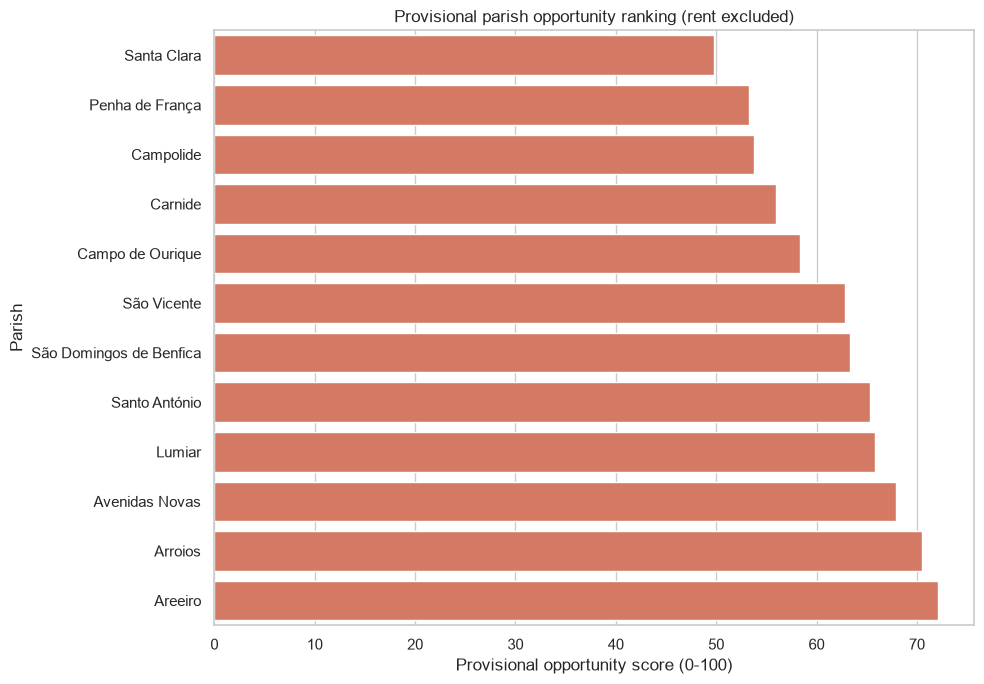

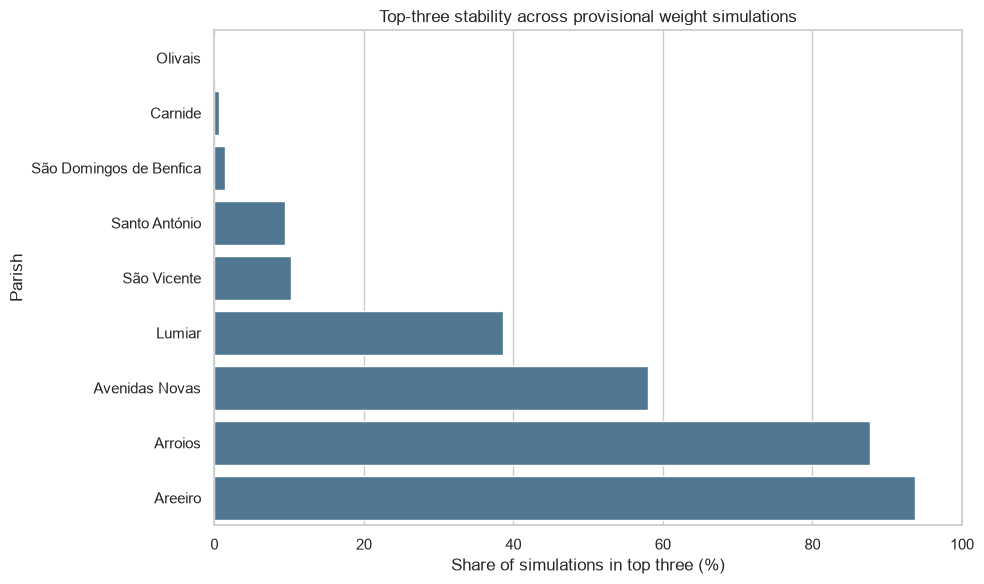

In [7]:
chart_data = ranking.nlargest(
    12,
    "provisional_opportunity_score",
).sort_values("provisional_opportunity_score")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=chart_data,
    x="provisional_opportunity_score",
    y="parish",
    color="#E76F51",
    ax=ax,
)
ax.set_title("Provisional parish opportunity ranking (rent excluded)")
ax.set_xlabel("Provisional opportunity score (0-100)")
ax.set_ylabel("Parish")
fig.tight_layout()
ranking_figure = FIGURES_DIR / "06_provisional_opportunity_ranking.png"
save_figure(fig, ranking_figure)
plt.show()

stability_data = (
    sensitivity[sensitivity["top3_share"].gt(0)]
    .sort_values("top3_share")
)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=stability_data,
    x="top3_share",
    y="parish",
    color="#457B9D",
    ax=ax,
)
ax.set_title(
    "Top-three stability across provisional weight simulations"
)
ax.set_xlabel("Share of simulations in top three (%)")
ax.set_ylabel("Parish")
ax.set_xlim(0, 100)
fig.tight_layout()
stability_figure = FIGURES_DIR / "07_provisional_top3_stability.png"
save_figure(fig, stability_figure)
plt.show()

## 8. Provisional conclusion and limitation

In [8]:
display(
    ranking.head(3)[
        [
            "parish",
            "provisional_opportunity_score",
            "provisional_rank",
            "top3_share",
            "median_rank",
        ]
    ]
)
print(
    "The citywide shortlist remains provisional. A separate "
    "rent-inclusive comparison is available for the ten "
    "candidate parishes with sufficient pilot coverage."
)

,parish,provisional_opportunity_score,provisional_rank,top3_share,median_rank
0,Areeiro,72.08,1,93.76,1.0
1,Arroios,70.55,2,87.70,2.0
2,Avenidas Novas,67.94,3,58.04,3.0


The citywide shortlist remains provisional. A separate rent-inclusive comparison is available for the ten candidate parishes with sufficient pilot coverage.


The provisional shortlist is useful for directing the next
research effort, but it is not the decision-focused shortlist.
Commercial asking rent covers the provisional top ten, but site
availability and local evidence must be considered when the
final three-area search scope is defined.